In [11]:
## Run to compare testing data for calibration models that included boh pre and post field data
## vs calibration models that only included pre field data

import sys
import pandas as pd
import os

sys.path.append(os.path.abspath(".."))
from data_tools import handle_datetime
from data_tools import process_dates
from data_tools.combine_data import CreateTrainingandTestData
combine = CreateTrainingandTestData()
from data_tools import plot_against_reference as plot
from data_tools import process_data as processed

year = "2025"
sensor_id = "McFarland"
calibration1 = "Both"
calibration2 = "Pre"

calibrated_file1 = rf"../reference_files/{year}OzoneDataCalibrated/{sensor_id}_calibrated{calibration1}.csv"
calibrated_file2 = rf"../reference_files/{year}OzoneDataCalibrated/{sensor_id}_calibrated{calibration2}.csv"

def create_o3_datetime(o3_file):
    o3df = pd.read_csv(o3_file, usecols = ['date_time','o3_calibrated', 'reference'])
    o3df = o3df.dropna(how='any')
    o3df = handle_datetime.create_standard_datetime(o3df)
    return o3df

calibrated_o3_both = create_o3_datetime(calibrated_file1)
calibrated_o3_pre = create_o3_datetime(calibrated_file2)


# Testing dates for both calibration types should be the same for consistency
testing_dates= process_dates.testing(sensor_id, year, calibration1)

testing_data_both = combine.subsection(calibrated_o3_both, testing_dates)
testing_data_pre = combine.subsection(calibrated_o3_pre, testing_dates)

# Add just the o3_calibrated column from testing_data_pre to testing_data_both
testing_data_both['o3_calibrated_pre'] = testing_data_pre['o3_calibrated']

# Optionally rename the original o3_calibrated for clarity
testing_data_both.rename(columns={'o3_calibrated': 'o3_calibrated_both'}, inplace=True)
testing_data_both = testing_data_both.dropna(how='any')

print(testing_data_both)




                     reference  o3_calibrated_both  o3_calibrated_pre
date_time                                                            
2025-07-05 06:30:00       19.4           20.877708          23.155010
2025-07-05 07:30:00       21.1           23.117739          24.471825
2025-07-05 08:30:00       26.4           27.587640          27.273314
2025-07-05 09:30:00       32.6           33.800524          32.571842
2025-07-05 10:30:00       36.7           37.286227          35.566156
...                        ...                 ...                ...
2025-07-10 02:30:00       31.1           31.377775          33.186010
2025-07-10 03:30:00       27.6           27.819143          30.496087
2025-07-10 04:30:00       23.8           23.501154          27.046268
2025-07-10 08:30:00       33.7           27.241915          26.555513
2025-07-10 09:30:00       47.6           37.141645          36.531819

[113 rows x 3 columns]


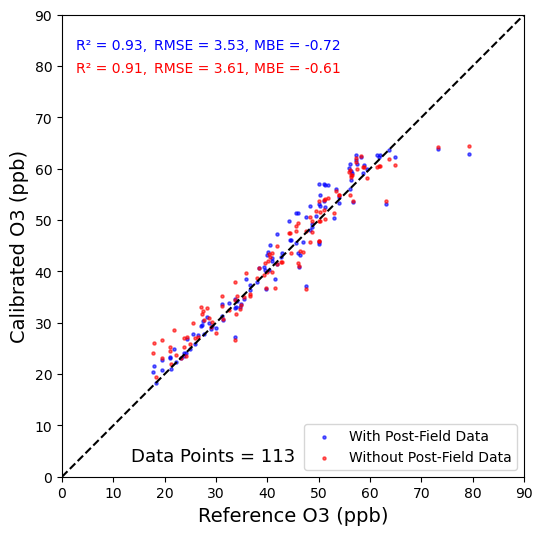

In [12]:
from data_tools.plot_against_reference import PlotOzone
po = PlotOzone()

po.plot_two_models(testing_data_both, sensor_id, "With Post-Field Data", "Without Post-Field Data", "o3_calibrated_both", "o3_calibrated_pre")


In [ ]:
## Run to see what training points were Pre vs. Post Field
import sys
import pandas as pd
import os

sys.path.append(os.path.abspath(".."))
from data_tools import handle_datetime
from data_tools import process_dates
from data_tools.combine_data import CreateTrainingandTestData
combine = CreateTrainingandTestData()
from data_tools import plot_against_reference as plot

year = "2025"
sensor_id = "Avenal"
calibration = "Both"

calibrated_file = rf"../reference_files/{year}OzoneDataCalibrated/{sensor_id}_calibrated{calibration}.csv"

o3df = pd.read_csv(calibrated_file, usecols = ['date_time','o3_calibrated', 'reference'])
o3df = o3df.dropna(how='any')
o3df = handle_datetime.create_standard_datetime(o3df)

training_dates= process_dates.training(sensor_id, year, calibration)
o3df = combine.subsection(o3df, training_dates)

o3df = o3df.dropna(how='any')

print(o3df)



                     reference  o3_calibrated
date_time                                    
2025-06-15 00:30:00  40.000000      39.624622
2025-06-15 01:30:00  35.600000      35.261952
2025-06-15 02:30:00  32.500000      31.645816
2025-06-15 03:30:00  29.400000      28.343916
2025-06-15 04:30:00  30.800000      28.835253
...                        ...            ...
2025-11-04 09:30:00  33.700000      34.047521
2025-11-04 10:30:00  36.566667      36.324414
2025-11-04 11:30:00  37.800000      36.443989
2025-11-04 12:30:00  40.958333      70.246807
2025-11-04 17:30:00  39.433333      40.637100

[479 rows x 2 columns]


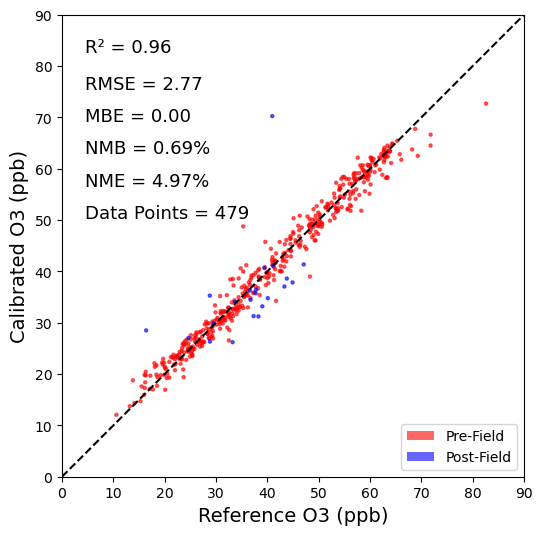

In [26]:
from data_tools.plot_against_reference import PlotOzone
po = PlotOzone()

po.plot(o3df,sensor_id,"Training",calibration, 'date')

In [27]:
## This code